In [ ]:
%reload_ext autoreload
%autoreload 2

# Benchmarking dependency measures for marker gene identification in multi-modal single-cell data
**Final project for the course Data Science in the Life Sciences, summer semester 2026**

Authors: Sören Seidack, Selina Wille, Jakob Kresse, Inbar Dagan

A **2×2** decomposition of dependency measures for identifying cell-type marker genes in
PBMC CITE-seq data (Hao et al. 2021), evaluated against a **protein-derived ground truth**
built from the ADT (surface-protein) modality.

|            | Marginal                     | Conditional                          |
|------------|------------------------------|--------------------------------------|
| **Linear**    | Spearman correlation         | Partial correlation (shrinkage)      |
| **Nonlinear** | Mutual information (KSG)      | Integrated Gradients on an MLP       |

Every method sees **RNA only**; the protein modality is used solely to define the
ground-truth driver set $D_c$ per cell type, keeping the evaluation a genuine cross-modal
test. Recovery of $D_c$ is scored with the parameter-free $\mathrm{AUC_{rel}}$ metric.

In [1]:
import os, sys, warnings
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")  # avoid OpenMP runtime clash

import numpy as np
import pandas as pd
import scipy.sparse as sp
import scanpy as sc
import matplotlib.pyplot as plt

from anndata import ImplicitModificationWarning
from pandas.errors import PerformanceWarning

# All project logic lives in the importable src/ package (see README).
from src import config
from src import ground_truth as gt
from src import stats as st
from src.preprocessing import rna as rna_pp, adt as adt_pp, normalization as norm_pp
from src.exploratory_analysis import dim_reduction as dr
from src.persistence import scoring_results as results_persistence
from measures.benchmarking import driver_recovery_metric
import src.plotting as P

warnings.simplefilter("ignore", category=PerformanceWarning)
warnings.simplefilter("ignore", category=ImplicitModificationWarning)
warnings.simplefilter("ignore", category=FutureWarning)
sc.settings.verbosity = 0
P.set_style()

LEVEL = config.DEFAULT_LEVEL      # celltype.l2 (~30 types)
DONOR = config.DONOR_KEY          # donor (8 donors) — the batch variable
SEED  = config.DEFAULT_SEED

# The scored result tables live in this repo (local_data/results). The expression
# matrices are NOT in this repo, so the exploratory section streams the processed
# ~25k-cell stratified subsample MuData produced by the pipeline.
H5MU = r"c:\Users\kr3ss\Desktop\data_science_project\my_pipeline\data\processed\pbmc3p_citeseq.h5mu"

def dense(x):
    return np.asarray(x.todense()) if sp.issparse(x) else np.asarray(x)

c:\Users\kr3ss\miniforge3\envs\marker-bench\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\kr3ss\miniforge3\envs\marker-bench\Lib\site-packages\muon\_core\preproc.py:31: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  if Version(scanpy.__version__) < Version("1.10"):


## 1. Data, QC and preprocessing

The Hao 2021 3′ CITE-seq data (GEO `GSE164378`: whole-transcriptome RNA + 228 surface
proteins + donor / `celltype.l1/l2/l3` labels) is streamed into a **sqrt-proportional
stratified subsample** (~25k cells) that retains rare PBMC types. We run the standard
Scanpy/muon workflow via the `src` package: RNA QC → `log1p`, ADT → **CLR**, and
`seurat_v3` HVG selection.

> **Note on data provenance.** The exploratory figures below use this ~25k subsample. The
> per-method *scores* analysed from §3 onward were produced by the cluster pipeline on the
> full dataset (`local_data/results/full_dataset_1`). The ground truth is a property of the
> cell types (which proteins mark them), so building it on a representative subsample to
> evaluate the full-dataset scores is sound.

In [2]:
import mudata as md

mdata = md.read_h5mu(H5MU)
rna, adt = mdata["rna"].copy(), mdata["adt"].copy()
rna.var["gene_name"] = rna.var_names.astype(str)
adt.var["protein_name"] = adt.var_names.astype(str)

# RNA: QC metrics (on raw counts) -> normalize + log1p -> HVGs (seurat_v3 on counts)
rna_pp.calculate_qc_metrics_in_place(rna)
norm_pp.normalize_in_place(rna)
rna_pp.annotate_highly_variable_genes(rna)

# ADT: centered-log-ratio (CITE-seq standard; controls per-cell staining depth)
adt.obs[LEVEL] = adt.obs[LEVEL].astype("category")
adt_pp.normalize_in_place(adt)

print(f"{rna.n_obs:,} cells | RNA {rna.n_vars:,} genes | ADT {adt.n_vars} proteins")
print(f"HVGs: {int(rna.var['highly_variable'].sum())}")
rna.obs[LEVEL].value_counts()

c:\Users\kr3ss\miniforge3\envs\marker-bench\Lib\site-packages\mudata\_core\mudata.py:565: UserWarning: Cannot join columns with the same name because var_names are intersecting.
  self._update_attr_legacy(attr, axis, join_common, **kwargs)


24,735 cells | RNA 33,538 genes | ADT 228 proteins
HVGs: 2000


celltype.l2
CD14 Mono            3037
CD4 Naive            1943
NK                   1926
CD4 TCM              1793
CD8 TEM              1592
CD8 Naive            1525
B naive              1291
CD16 Mono            1168
CD4 TEM               962
gdT                   888
B memory              842
CD8 TCM               789
MAIT                  775
Treg                  736
cDC2                  735
B intermediate        725
Platelet              704
CD4 CTL               612
NK_CD56bright         451
pDC                   431
NK Proliferating      344
Plasmablast           281
dnT                   277
HSPC                  267
cDC1                  151
ILC                   132
CD4 Proliferating     108
CD8 Proliferating      91
Eryth                  83
ASDC                   76
Name: count, dtype: int64

### 1.1 Quality control

Per-cell library size, gene complexity, and mitochondrial fraction. The subsample is already
quality-filtered upstream, so these are confirmatory.

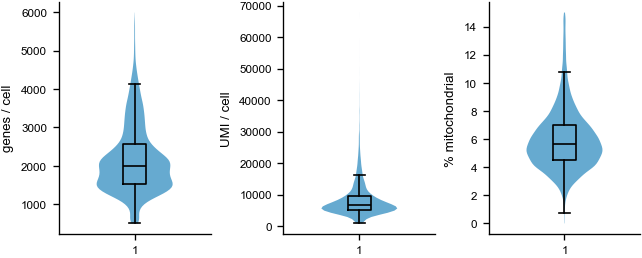

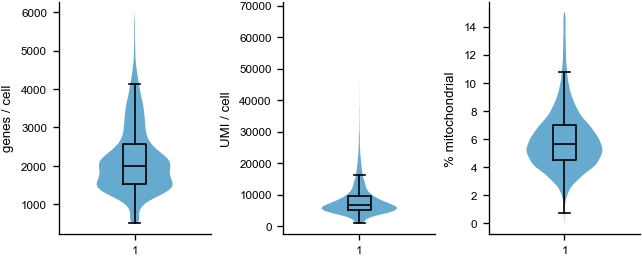

In [3]:
qc = rna.obs[["n_genes_by_counts", "total_counts", "pct_counts_mt"]].rename(
    columns={"n_genes_by_counts": "genes / cell", "total_counts": "UMI / cell",
             "pct_counts_mt": "% mitochondrial"})
fig = P.qc_violins(qc, list(qc.columns))
fig

### 1.2 Exploratory analysis: UMAP, donor batch effect, label validation

PCA → UMAP on the scaled HVGs, with **Harmony** batch correction over the 8 donors. The
donor UMAPs (before / after Harmony) show whether batch correction is warranted; the
cell-type UMAP shows the lineage structure the RNA methods must exploit.

In [4]:
rna_h = rna[:, rna.var["highly_variable"]].copy()
sc.pp.scale(rna_h, max_value=10)
dr.perform_pca_in_place(rna_h)            # X_pca
dr.perform_umap_in_place(rna_h)           # X_umap
dr.perform_pca_harmony_in_place(rna_h)    # X_pca_harmony (Harmony over donors)
dr.perform_umap_harmony_in_place(rna_h)   # X_umap_harmony

CT = rna.obs[LEVEL].astype(str).values
DON = rna.obs[DONOR].astype(str).values
print("embeddings:", [k for k in rna_h.obsm])

c:\Users\kr3ss\miniforge3\envs\marker-bench\Lib\functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)
2026-07-05 10:57:27,497 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
c:\Users\kr3ss\miniforge3\envs\marker-bench\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
2026-07-05 10:57:29,843 - harmonypy - INFO - sklearn.KMeans initialization complete.
2026-07-05 10:57:29,907 - harmonypy - INFO - Iteration 1 of 10
2026-07-05 10:57:31,743 - ha

embeddings: ['X_pca', 'X_umap', 'X_pca_harmony', 'X_umap_harmony']


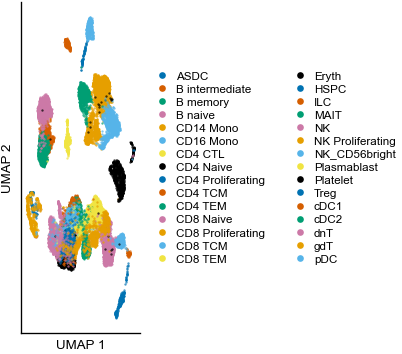

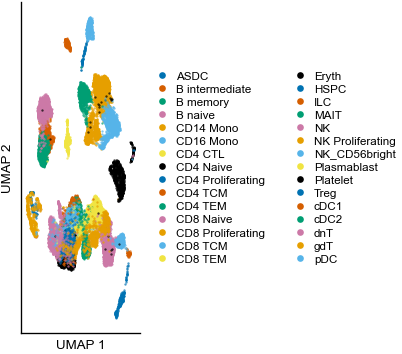

In [5]:
fig, _ = P.embedding_scatter(rna_h.obsm[dr.OBSM_NAME_UMAP], CT, legend_ncol=2)
fig  # UMAP coloured by cell type

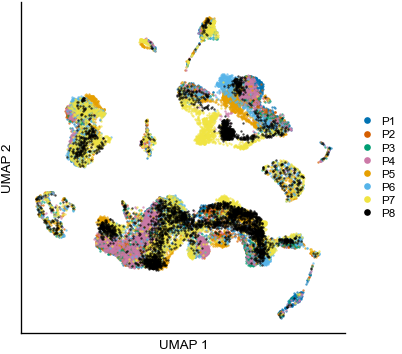

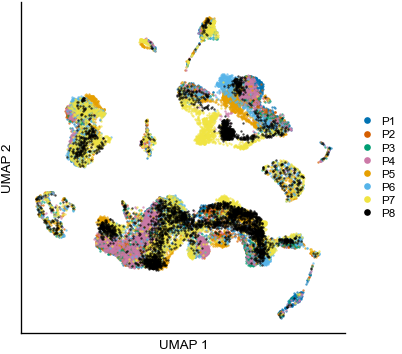

In [6]:
fig, _ = P.embedding_scatter(rna_h.obsm[dr.OBSM_NAME_UMAP], DON)
fig  # UMAP coloured by donor — BEFORE Harmony (look for donor-driven islands)

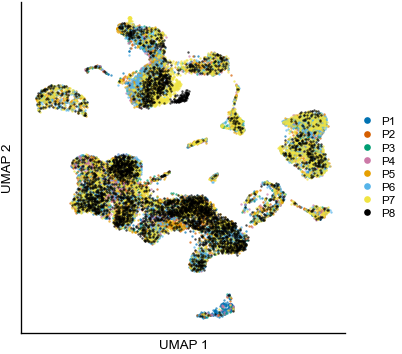

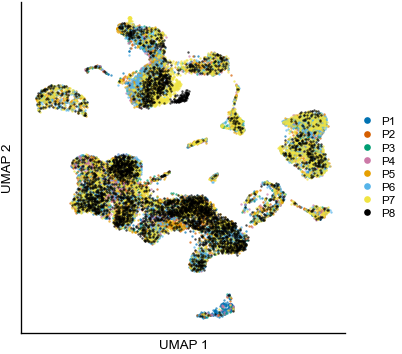

In [7]:
fig, _ = P.embedding_scatter(rna_h.obsm[dr.OBSM_NAME_UMAP_HARMONY], DON)
fig  # UMAP coloured by donor — AFTER Harmony (donors should intermix)

Cell-type labels validated against the **independent protein channel**: mean CLR
surface-protein level per cell type (z-scored per protein). The block structure
(CD3→T, CD19/CD20→B, CD14→monocytes, CD56→NK, …) confirms the WNN labels agree with direct
molecular evidence.

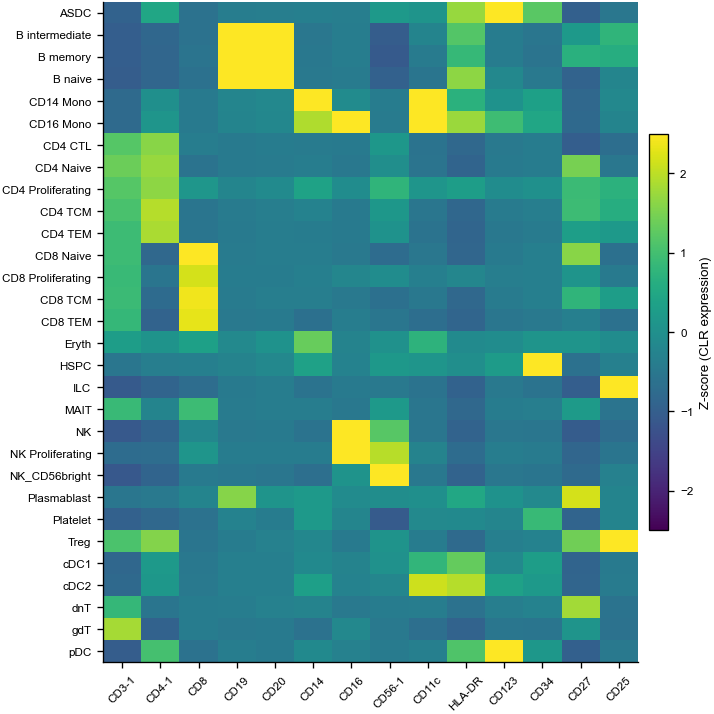

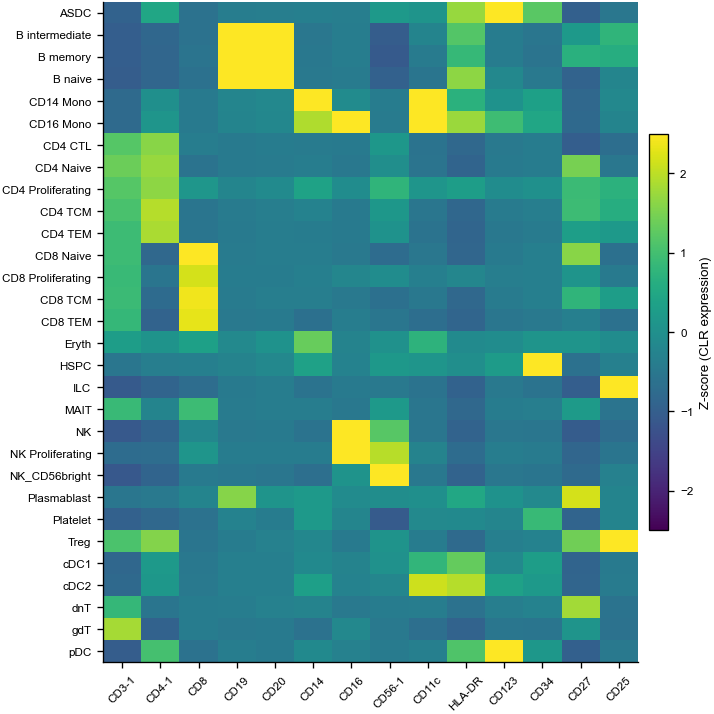

In [8]:
key = [p for p in ["CD3-1","CD4-1","CD8","CD19","CD20","CD14","CD16","CD56-1",
                   "CD11c","HLA-DR","CD123","CD34","CD27","CD25"] if p in adt.var_names]
clr_df = pd.DataFrame(dense(adt.layers[adt_pp.LAYER_NAME_CENTERED_LOG_RATIO]),
                      columns=adt.var_names)
clr_df["ct"] = CT
means = clr_df.groupby("ct")[key].mean()
matz = (means - means.mean()) / means.std()
fig, _ = P.protein_marker_validation_heatmap(matz)
fig

## 2. Protein-derived ground truth $D_c$ (CLR)

For each cell type we take the top surface proteins by one-vs-rest **Wilcoxon score on
CLR-normalised ADT** (p-values are uninformative at n≈25k), then map each protein to its
encoding gene(s) by molecular fact only (UniProt/HGNC curation in `src.mappings`),
intersected with the scored gene universe. This is independent of all four RNA methods.

> **Normalization choice.** We use the **CLR** layer, the CITE-seq standard that removes
> per-cell staining/sequencing-depth confounding (Stoeckius 2017), rather than a plain
> `log1p` (which for a one-vs-rest Wilcoxon is monotonic per protein and hence equivalent to
> a raw-count test). `build_ground_truth(..., layer=...)` makes this switchable.

In [9]:
methods_present = [config.METHOD_SPEARMAN, config.METHOD_PARTIAL_CORRELATION,
                   config.METHOD_IG_MLP]
scores = results_persistence.load_multiple_results(
    methods=methods_present, subsample_size=-1, test_split_size=40,
    root_dir=config.LOCAL_RESULTS_ROOT / "full_dataset_1")
gene_universe = scores[methods_present[0]].index.tolist()

drivers, gt_details = gt.build_ground_truth(
    adt, genes_of_interest=gene_universe, level=LEVEL,
    layer=adt_pp.LAYER_NAME_CENTERED_LOG_RATIO)

gt_summary = (pd.DataFrame({"celltype": list(drivers),
                            "n_drivers": [len(v) for v in drivers.values()],
                            "drivers": [", ".join(sorted(v)) for v in drivers.values()]})
              .sort_values("n_drivers", ascending=False).reset_index(drop=True))
gt_summary

,celltype,n_drivers,drivers
0,B memory,8,"CCR6, CD19, CD22, CD40, CR2, MS4A1, NT5E, PTPRC"
1,B intermediate,7,"CCR6, CD19, CD22, CD72, CR2, MS4A1, PTPRC"
2,CD8 TCM,7,"CD2, CD28, CD8A, CD8B, CD99, IL7R, KLRK1"
3,CD8 Naive,7,"CD27, CD8A, CD8B, IL7R, KLRK1, NT5E, PTPRC"
4,NK_CD56bright,7,"CD2, CD244, KIT, KLRK1, NCR1, NCR3, PTPRC"
5,ILC,7,"IL2RA, IL7R, KIT, KLRB1, NCR1, PTPRC, TFRC"
6,dnT,7,"CD27, CD28, CD81, ICOS, KLRK1, PTPRC, TIGIT"
7,CD14 Mono,6,"CD14, CD93, CLEC12A, FCGR1A, ITGB2, PVR"
8,CD8 TEM,6,"B3GAT1, CD2, CD8A, CD8B, KLRK1, TIGIT"
9,NK,6,"CD244, FCGR3A, FCGR3B, NCR1, NCR3, PTPRC"


## 3. The scored dependency measures

All four methods operate on the identical shared feature matrix and a binary one-vs-rest
indicator; scoring is expensive, so it is run on the cluster and the per-gene score tables
are loaded here.

* **Spearman** (linear · marginal) and **partial correlation** (linear · conditional) and
  **Integrated Gradients on the MLP** (nonlinear · conditional) are available for the full
  dataset and compared below.
* **Mutual information (KSG)** — the nonlinear · marginal cell — was only scored for the 10k
  subsample run in this checkout, so it is omitted from the full-dataset comparison to keep
  the cell set identical across methods. Drop its results into `full_dataset_1` to include it.

**Integrated Gradients uses the attribution _magnitude_** $|\mathrm{IG}|$: IG feature
importance is unsigned, and Inbar's stored attributions are signed (~52% negative, mean≈0),
so ranking by the raw signed value is near-random (AUC≈0.52) while $|\mathrm{IG}|$ recovers
drivers well.

In [ ]:
# IG feature importance = |attribution| (see note above)
scores[config.METHOD_IG_MLP] = scores[config.METHOD_IG_MLP].abs()

valid = [ct for ct in scores[methods_present[0]].columns
         if ct in drivers and len(drivers[ct]) >= config.MIN_DRIVERS]
print(f"methods: {[config.METHOD_LABELS[m] for m in methods_present]}")
print(f"scored genes: {len(gene_universe)} | evaluable cell types (>= "
      f"{config.MIN_DRIVERS} drivers): {len(valid)}/{scores[methods_present[0]].shape[1]}")

## 4. Cross-method comparison — driver recovery ($\mathrm{AUC_{rel}}$)

$\mathrm{AUC_{rel}}$ is the normalized driver-recovery AUC (Mann–Whitney ROC-AUC of the
per-gene score discriminating drivers from non-drivers): 0.5 = random, 1.0 = perfect,
parameter-free, defined on every method's output. We compute it **per cell type** (the unit
of replication) using `driver_recovery_metric`.

In [ ]:
rows = [{"celltype": ct, "method": m,
         "auc_rel": driver_recovery_metric.compute_auc_rel(scores[m][[ct]], {ct: drivers[ct]})}
        for m in methods_present for ct in valid]
auc_long = pd.DataFrame(rows)
auc_wide = auc_long.pivot_table(index="celltype", columns="method", values="auc_rel")
auc_wide.loc["— mean —"] = auc_wide.mean()
auc_wide.round(3)

Cumulative driver-recovery curves **pooled over cell types** — the area under each is
$\mathrm{AUC_{rel}}$ for that method.

In [ ]:
driver_recovery_metric.plot(
    [scores[m].loc[:, valid] for m in methods_present],
    [config.METHOD_LABELS[m] for m in methods_present],
    {ct: drivers[ct] for ct in valid})
plt.gcf()

In [ ]:
fig, _ = P.auc_box(auc_long, methods_present)
fig  # AUC_rel per method, one point per cell type

In [ ]:
wide = st.pivot_auc(auc_long)
fig, _ = P.auc_heatmap(wide, method_order=methods_present)
fig  # cell-type x method AUC_rel

## 5. Statistical comparison

The unit of replication is the **cell type** (paired across methods): a Friedman omnibus
test, then Holm-corrected pairwise Wilcoxon signed-rank tests with matched-pairs
rank-biserial effect sizes.

In [ ]:
fried = st.friedman_test(wide)
print(f"Friedman chi2 = {fried['statistic']:.2f}, p = {fried['pvalue']:.2e} "
      f"(n = {fried['n_celltypes']} cell types)")
pw = st.pairwise_wilcoxon(wide, method_order=methods_present)
pw

In [ ]:
sig = [(r.method_a, r.method_b, "*" if r["significant_0.05"] else "ns")
       for _, r in pw.iterrows()]
fig, _ = P.auc_box(auc_long, methods_present, sig_pairs=sig)
fig  # with pairwise significance brackets

## 6. Cross-method comparison (gene level)

Pooling every (gene, cell type) score (z-scored within cell type), how do the measures
relate, and where do the protein-confirmed drivers sit? Drivers are highlighted; the
diagonal shows each score distribution and the upper triangle the Spearman ρ between
methods.

In [ ]:
parts = [scores[m].loc[:, valid].reset_index()
              .melt(id_vars="gene_name", var_name="celltype", value_name=m)
              .set_index(["gene_name", "celltype"])
         for m in methods_present]
long = pd.concat(parts, axis=1).reset_index()
long["is_driver"] = [g in drivers.get(ct, set())
                     for g, ct in zip(long["gene_name"], long["celltype"])]
for m in methods_present:
    long[m] = long.groupby("celltype")[m].transform(lambda v: (v - v.mean()) / (v.std() + 1e-9))

fig, _ = P.pairwise_scatter_matrix(long, methods_present)
fig

## 7. Interpretation and caveats

**What the benchmark shows (this checkout, L2, CLR ground truth).** Against the
protein-derived driver sets, the **marginal linear** measure (Spearman) and the
**conditional linear** measure (partial correlation) recover drivers best and are
statistically indistinguishable from each other; **Integrated Gradients on the MLP**
(nonlinear · conditional, using $|\mathrm{IG}|$) is close behind. The Friedman test rejects
equality across methods, and the pairwise Wilcoxon tests localise the differences (see §5).
Under this evaluation, *nonlinearity / multivariate context does not improve* marginal
marker recovery — the simple correlation is a strong baseline.

**Caveats.**
- **Cross-source evaluation.** Ground truth is built on the ~25k subsample ADT; the scores
  are from the full-dataset cluster run. Cell-type definitions match, but this is not a
  single self-consistent run.
- **IG sign convention.** IG-MLP uses $|\mathrm{IG}|$; the raw signed attributions are
  near-random against $D_c$ — worth confirming how the attributions were exported.
- **MI (KSG) missing** for the full dataset in this checkout; the 2×2 is therefore reported
  as a 3-cell comparison here.
- Bootstrap-over-cells and MLP-seed stability bands (descriptive, not inferential) are
  produced by `run_pipeline.py` and can be loaded here when available.